In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
data = pd.read_csv('train.csv')

In [5]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
data = np.array(data)
m,n = data.shape
np.random.shuffle(data)

In [22]:
train = data[0:int(0.8*m), :]
valid = data[int(0.8*m):m, :]

x_train = train[:, 1:].T/255.0 # shape = (784, 33600)
y_train = train[:, 0]     # shape = (33600,)
x_val   = valid[:, 1:].T /255.0 # shape = (784, 8400)
y_val   = valid[:, 0]     # shape = (8400,)


In [23]:
import numpy as np

def initialize_params():
    w1 = np.random.rand(10,784)-0.5
    b1 = np.random.rand(10,1)-0.5
    w2 = np.random.rand(10,10)-0.5
    b2 = np.random.rand(10,1)-0.5
    return w1, b1, w2, b2

def ReLU(x): return np.maximum(x,0)

def softmax(z):
    z -= np.max(z, axis=0, keepdims=True) 
    return np.exp(z) / np.sum(np.exp(z), axis=0, keepdims=True)

def forward(w1, b1, w2, b2, x):
    z1 = w1.dot(x) + b1
    a1 = ReLU(z1)
    z2 = w2.dot(a1) + b2                  
    a2 = softmax(z2)
    return z1, a1, z2, a2

def one_hot_y(y):
    ohy = np.zeros((y.size, y.max()+1))
    ohy[np.arange(y.size), y] = 1
    return ohy.T

def backward(w1, b1, w2, b2, z1, a1, z2, a2, x, y):
    m = x.shape[1]                         
    ohy = one_hot_y(y)
    dz2 = a2 - ohy
    dw2 = 1/m * dz2.dot(a1.T)
    db2 = 1/m * np.sum(dz2, axis=1, keepdims=True)
    dz1 = w2.T.dot(dz2) * (z1 > 0)
    dw1 = 1/m * dz1.dot(x.T)
    db1 = 1/m * np.sum(dz1, axis=1, keepdims=True)
    return dw1, db1, dw2, db2

def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, lr):
    w1 = w1 - lr*dw1
    b1 = b1 - lr*db1
    w2 = w2 - lr*dw2
    b2 = b2 - lr*db2
    return w1, b1, w2, b2

def predict(a2): return np.argmax(a2, 0)
def accuracy(predictions, y): return np.sum(predictions == y) / y.size

def gradient_descent(x, y, alpha, epochs):
    w1, b1, w2, b2 = initialize_params()
    for i in range(1, epochs+1):
        z1,  a1,  z2,  a2  = forward(w1, b1, w2, b2, x)
        dw1, db1, dw2, db2 = backward(w1, b1, w2, b2, z1, a1, z2, a2, x, y)
        w1,  b1,  w2,  b2  = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha)
        if not i % 100:
            print(f"Iteration {i}: Accuracy: {accuracy(predict(a2), y):.4f}")
    return w1, b1, w2, b2                  



In [25]:
w1, b1, w2, b2 = gradient_descent(x_train, y_train, 0.01, 00)

Iteration 100: Accuracy: 0.2066
Iteration 200: Accuracy: 0.2525
Iteration 300: Accuracy: 0.3015
Iteration 400: Accuracy: 0.3484
Iteration 500: Accuracy: 0.3986
Iteration 600: Accuracy: 0.4496
Iteration 700: Accuracy: 0.4931
Iteration 800: Accuracy: 0.5331
Iteration 900: Accuracy: 0.5681
Iteration 1000: Accuracy: 0.6004
Iteration 1100: Accuracy: 0.6280
Iteration 1200: Accuracy: 0.6513
Iteration 1300: Accuracy: 0.6710
Iteration 1400: Accuracy: 0.6872
Iteration 1500: Accuracy: 0.7013


In [37]:
w1, b1, w2, b2 = gradient_descent(x_train, y_train, 0.1, 2000)

Iteration 100: Accuracy: 0.5879
Iteration 200: Accuracy: 0.7574
Iteration 300: Accuracy: 0.8033
Iteration 400: Accuracy: 0.8274
Iteration 500: Accuracy: 0.8429
Iteration 600: Accuracy: 0.8554
Iteration 700: Accuracy: 0.8645
Iteration 800: Accuracy: 0.8712
Iteration 900: Accuracy: 0.8771
Iteration 1000: Accuracy: 0.8805
Iteration 1100: Accuracy: 0.8846
Iteration 1200: Accuracy: 0.8874
Iteration 1300: Accuracy: 0.8893
Iteration 1400: Accuracy: 0.8918
Iteration 1500: Accuracy: 0.8940
Iteration 1600: Accuracy: 0.8965
Iteration 1700: Accuracy: 0.8985
Iteration 1800: Accuracy: 0.9002
Iteration 1900: Accuracy: 0.9018
Iteration 2000: Accuracy: 0.9034


Enter value between 1 and 784 inclusive 421


Predicted : [3]
Actual : 3


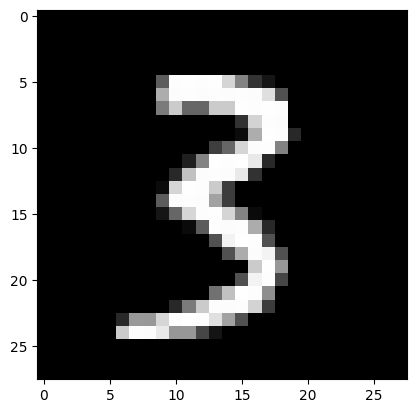

In [38]:
val_idx = int(input("Enter value between 1 and 784 inclusive"))
z1val, a1val, z2val, a2val = forward(w1, b1, w2, b2, x_val[:, val_idx, None])
print("Predicted :", predict(a2val))
print("Actual :", y_val[val_idx])
img_arr = x_val[:,val_idx].reshape(28,28)
plt.imshow(img_arr, cmap= 'gray')
plt.show()